# 센서 전개 후 결합 안정성

고정 길이 견인 상태의 기체·센서·케이블을 함께 선형화하고 작은 교란 응답과 비교합니다. 전개·접촉 중의 안정성을 이 고유값으로 판정하지 않습니다.

## 실행 준비

프로젝트 전용 환경에서 실행합니다. 먼저 README의 `build-aero` 명령으로 실제 AVL 데이터를 생성해야 합니다. 예시 입력은 팀 기체의 설계값이 아닙니다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbf_stability import *
from dbf_stability.analysis import load_result
ROOT = Path.cwd() if (Path.cwd() / "examples").exists() else Path.cwd().parent
c = load_case(ROOT / "examples/reference.yaml")
aero = AeroDatabase(ROOT / "outputs/aero_database.npz")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)
print("Actual solver:", aero.metadata["solver"])
print("Raw solver files:", aero.metadata["raw_directory"])


Actual solver: AVL 3.52
Raw solver files: D:\DBF\안정성 툴\outputs\avl_runs_5f9062ee


## 평형과 고유값

In [2]:
trim = solve_trim(c, aero)
stability = analyze_stability(c, aero, trim)
stability['modes'].head(16)

,real_1_s,imag_rad_s,frequency_hz,damping_ratio,classification
0,1.057115e-02,0.000000,0.000000e+00,-1.000000,unstable
1,1.778800e-09,0.000001,2.112128e-07,-0.001340,neutral_kinematic
2,1.778800e-09,-0.000001,2.112128e-07,-0.001340,neutral_kinematic
3,2.691945e-12,0.000000,0.000000e+00,NaN,neutral_kinematic
4,-8.213249e-11,0.000000,0.000000e+00,NaN,neutral_kinematic
5,-4.970214e-02,0.566784,9.020644e-02,0.087356,stable
6,-4.970214e-02,-0.566784,9.020644e-02,0.087356,stable
7,-7.406605e-02,0.000000,0.000000e+00,1.000000,stable
8,-1.431814e-01,3.768998,5.998546e-01,0.037962,stable
9,-1.431814e-01,-3.768998,5.998546e-01,0.037962,stable


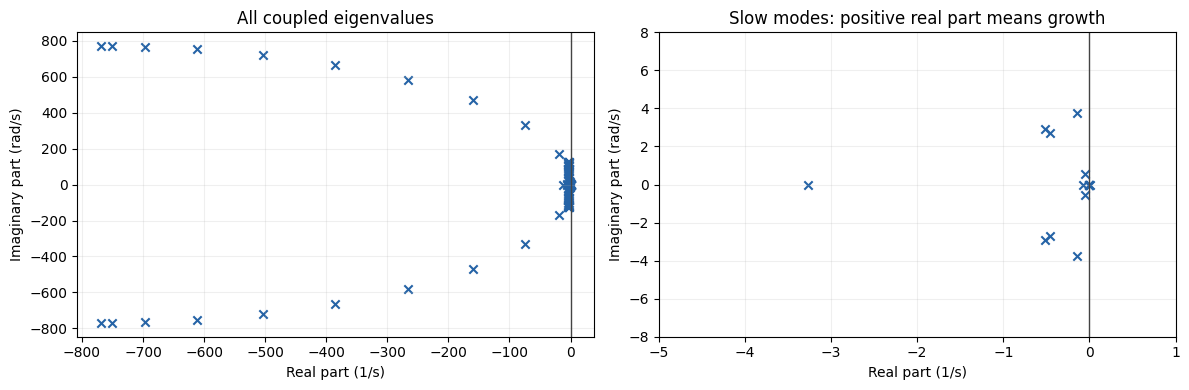

Local growing mode present: True


In [3]:
modes = stability['modes']
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax in axes:
    ax.scatter(modes.real_1_s, modes.imag_rad_s, marker='x', color='#2563a6')
    ax.axvline(0,color='#444444',linewidth=1)
    ax.set(xlabel='Real part (1/s)',ylabel='Imaginary part (rad/s)')
axes[0].set_title('All coupled eigenvalues')
axes[1].set(xlim=(-5,1),ylim=(-8,8),title='Slow modes: positive real part means growth')
fig.tight_layout();plt.show()
print('Local growing mode present:', stability['unstable'])

## 센서 피치에 작은 교란 적용

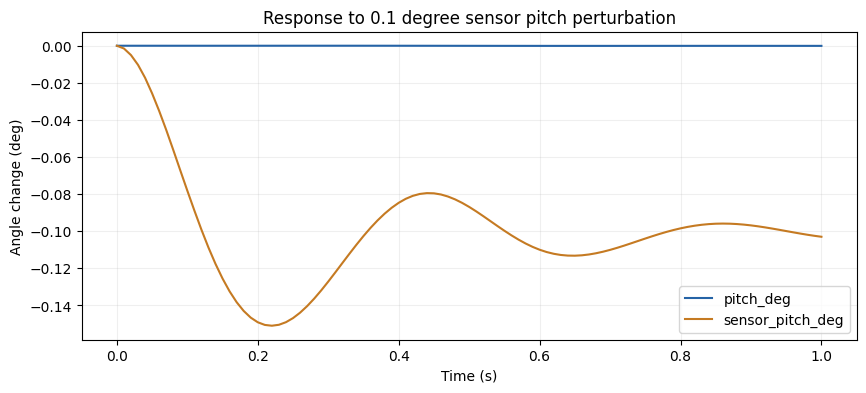

'completed'

In [4]:
perturbed = changed(c, **{'flight.initial_sensor_angles_delta_deg':[0,0.1,0]})
response = simulate(perturbed, aero, trim, phase='deployed', duration=1.0)
fig, ax = plt.subplots()
for key, color in [('pitch_deg','#2563a6'),('sensor_pitch_deg','#c57a22')]:
    ax.plot(response.time, response.table[key]-response.table[key].iloc[0], label=key, color=color)
ax.set(xlabel='Time (s)',ylabel='Angle change (deg)',title='Response to 0.1 degree sensor pitch perturbation')
ax.legend(); plt.show()
response.summary['status']

## 판독

실수부가 양수인 고유값은 해당 평형에서 교란이 커지는 모드를 뜻합니다. 0 부근의 운동학적 모드와 구분해 읽어야 합니다. 짧은 시간 그래프에서 변화가 작아도 느린 발산 모드가 없다는 뜻은 아닙니다.